In [1]:
from google.colab import drive
import pandas as pd
import numpy as np

drive.mount('/content/drive')


path = '/content/drive/My Drive/Data_sets/Social_Network_Ads.csv'

df=pd.read_csv(path)
df.head()

Mounted at /content/drive


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [2]:
#df.isna().sum()
X=df.iloc[:,2:4].values
y=df.iloc[:,-1].values

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)
#

In [3]:
from sklearn.ensemble import RandomForestClassifier
classifier=RandomForestClassifier(n_estimators=10,criterion='entropy')
classifier.fit(X_train,y_train)

from sklearn.metrics import accuracy_score
y_pred=classifier.predict(X_test)
acc=accuracy_score(y_test,y_pred)
print(acc)


0.8625


[[46  6]
 [ 5 23]]


<Axes: >

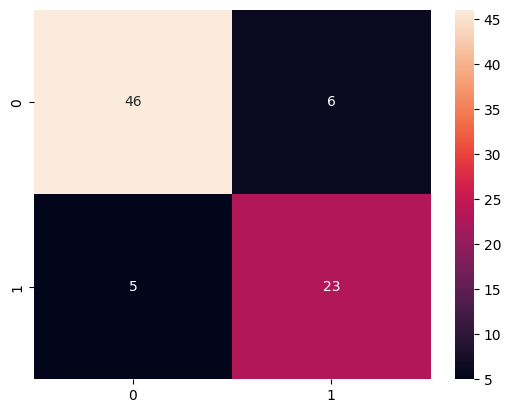

In [4]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

import seaborn as sns
sns.heatmap(cm,annot=True)

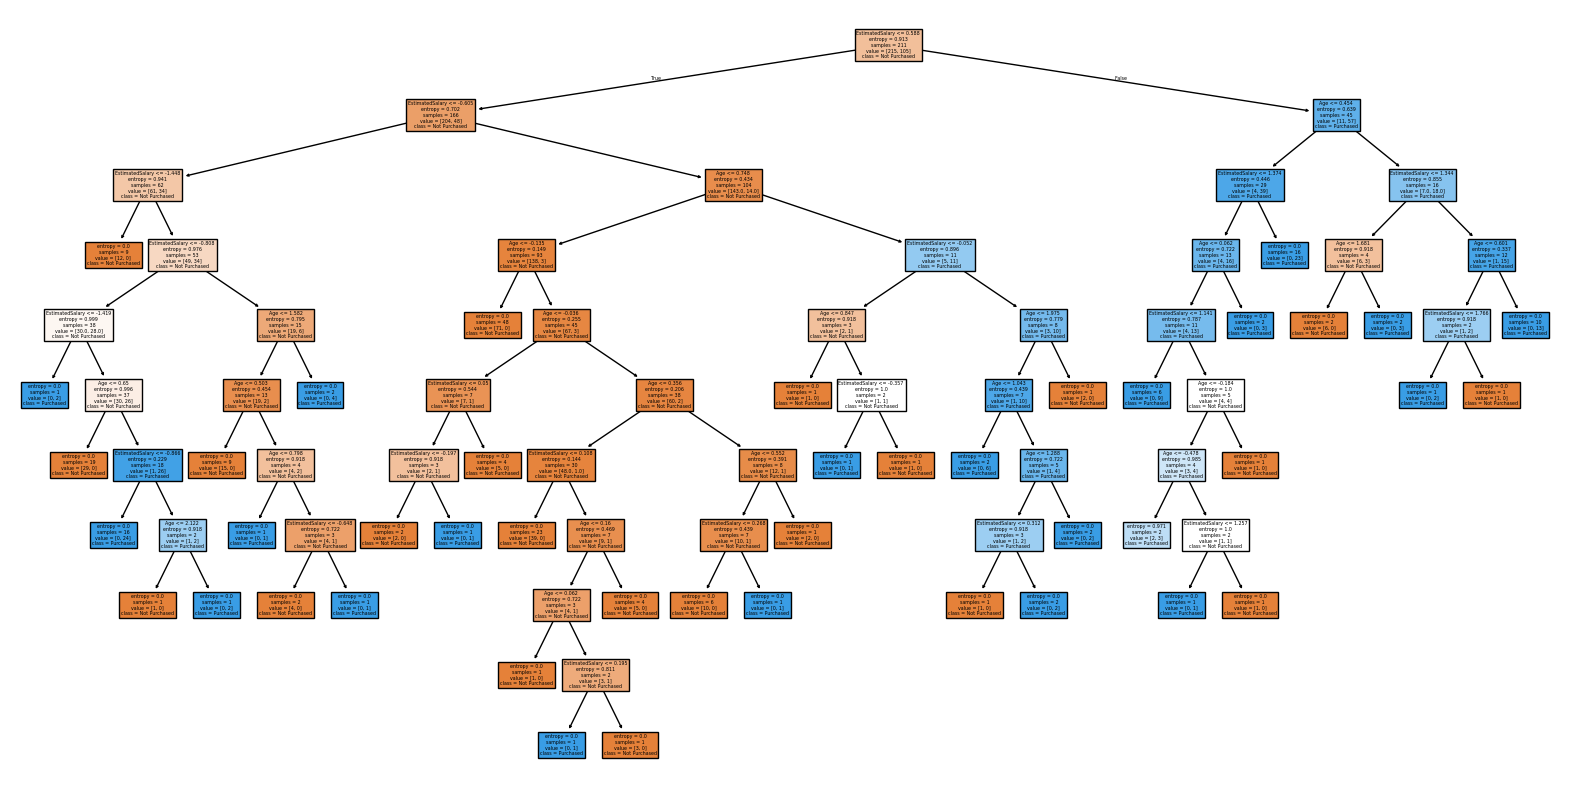

In [5]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(classifier.estimators_[0],feature_names=['Age', 'EstimatedSalary'],class_names=['Not Purchased', 'Purchased'],filled=True)
plt.show()